# Signal Method Comparison: Fixed, Rolling, and Cross-Sectional Rules

**Docker image**: `ml4t`

**Chapter 16: Strategy Simulation**
**Book reference:** Section 16.2, trading protocol specification
**Prerequisites:** Approved ETF and crypto GBM validation prediction registries

This notebook provides a systematic comparison of different signal conversion methods
for converting ML prediction scores into actionable trading signals.

**Learning Objectives:**
1. Compare fixed threshold vs rolling percentile signal methods
2. Understand the tradeoff between signal frequency and adaptability
3. Measure per-symbol signal-state transitions without calling them turnover
4. Separate implementation diagnostics from return and cost evaluation

**Key Question:** How do we convert a continuous regression score `y_score`
into a binary trading signal? The ETF and crypto regression scores compared
here are signed predictions, not probabilities. A zero cutoff therefore has
a direct interpretation: enter when the model predicts a positive return.
Percentile rules instead define a relative cutoff from recent or
cross-sectional scores.

**Methods Compared:**
1. **Fixed Threshold**: Signal when `y_score > threshold`. Useful when scores
   are calibrated to a fixed scale; degenerate on these uncalibrated
   regression scores.
2. **Rolling Percentile**: Signal when `y_score` exceeds the $N^{\text{th}}$
   percentile of the trailing window. Adapts to drifting score scale.
3. **Cross-Sectional**: Signal for the top $N\%$ of assets at each timestamp.
   Adapts across the universe rather than over time.

## Setup

In [1]:
"""Compare fixed, rolling-percentile, and cross-sectional signal conversion."""

import hashlib
import math
import sqlite3
import warnings
from pathlib import Path

import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

In [2]:
from case_studies.utils.signals import (
    cross_sectional_percentile_signal,
    fixed_threshold_signal,
    rolling_percentile_signal,
)
from utils.paths import get_case_study_dir, get_output_dir
from utils.style import COLORS

# The approved prediction set is pinned by the identity the selector resolves to,
# not by a SHA-256 of the registry file. A registry is a SQLite database that is
# rewritten whenever a run is recorded and sampled down for CI, so its bytes
# differ between the teaching registry and the test fixture by construction: one
# constant cannot be correct in both, and the pin that was here matched neither.
# The resolved config and prediction hash are the same in both, and they are what
# the section actually depends on - which model won the selection.
CASE_STUDIES = {
    "crypto_perps_funding": {
        "label": "fwd_ret_24h",
        "display": "Crypto perpetuals",
        "registry_status": "accepted",
        "config_name": "leaves_31_mae",
        "prediction_hash": "f6bd7cd2d208",
    },
    "etfs": {
        "label": "fwd_ret_21d",
        "display": "ETFs",
        "registry_status": "accepted_pre_ipca",
        "config_name": "leaves_7_mae",
        "prediction_hash": "226acb97bed9",
    },
}
REGISTRY_MAP_SHA256 = "624ff8dd52251d97ffe770a027edd24b3b9f7899d1da00c24ad4e8c843405d3e"
ROLLING_WINDOWS = [21, 42, 63]
PERCENTILES = [75, 80, 85, 90, 95]
CASE_STUDY_COLORS = {
    "crypto_perps_funding": COLORS["blue"],
    "etfs": COLORS["amber"],
}

### Resolve One Registered Prediction Set

Each case study contributes one complete GBM validation prediction set. The
selector ranks complete candidates by mean daily cross-sectional rank IC, the
same statistic used for reporting, and then reads the exact registered
parquet. Registry identities come from the approved v3.1 teaching map whose
SHA-256 is recorded with the output.

In [3]:
SELECTOR_SQL = """
    WITH candidates AS (
        SELECT t.config_name, p.prediction_hash, p.checkpoint_value,
               pm.ic_mean_daily, pm.ic_n_days,
               MAX(pm.ic_n_days) OVER () AS max_n_days
        FROM training_runs AS t
        JOIN prediction_sets AS p USING (training_hash)
        JOIN prediction_metrics AS pm USING (prediction_hash)
        WHERE t.family = ? AND t.label = ? AND p.split = 'validation'
          AND pm.ic_mean_daily IS NOT NULL AND pm.ic_n_days IS NOT NULL
    )
    SELECT config_name, prediction_hash, checkpoint_value, ic_mean_daily, ic_n_days
    FROM candidates
    WHERE ic_n_days = max_n_days
    ORDER BY ic_mean_daily DESC, prediction_hash
    LIMIT 1
"""

In [4]:
def select_registered_prediction(db_path: Path, family: str, label: str) -> dict[str, object]:
    """Select the highest-rank-IC prediction set among maximum-coverage candidates."""
    with sqlite3.connect(f"file:{db_path}?mode=ro", uri=True) as connection:
        row = connection.execute(SELECTOR_SQL, (family, label)).fetchone()
    if row is None:
        raise RuntimeError(f"No complete {family} validation predictions for {label}")

    keys = ["config_name", "prediction_hash", "checkpoint_value", "daily_rank_ic", "n_days"]
    return dict(zip(keys, row, strict=True))

The selected parquet must conserve its registered coverage and rank IC. This
catches stale or mismatched prediction artifacts before any signal rule runs.

In [5]:
def validate_prediction_set(pred_path: Path, metadata: dict[str, object]) -> pl.DataFrame:
    """Validate the selected prediction artifact against its registry metrics."""
    raw_predictions = pl.read_parquet(pred_path)
    required = {"timestamp", "symbol", "fold", "prediction", "actual"}
    if not required.issubset(raw_predictions.columns):
        raise RuntimeError(f"Prediction schema is incomplete in {pred_path}")
    predictions = raw_predictions.rename(
        {"prediction": "y_score", "actual": "y_true", "fold": "fold_id"}
    )
    if predictions.select("timestamp", "symbol").is_duplicated().any():
        raise RuntimeError(f"Duplicate timestamp-symbol rows in {pred_path}")
    if (
        predictions.select("timestamp", "symbol", "y_score", "y_true", "fold_id")
        .null_count()
        .sum_horizontal()
        .item()
        != 0
    ):
        raise RuntimeError(f"Null required values in {pred_path}")
    daily_ic = (
        predictions.group_by("timestamp")
        .agg(pl.corr("y_score", "y_true", method="spearman").alias("rank_ic"))
        .filter(pl.col("rank_ic").is_not_null())
    )
    if daily_ic.height != int(metadata["n_days"]):
        raise RuntimeError(f"Daily IC coverage mismatch in {pred_path}")
    if not math.isclose(
        daily_ic["rank_ic"].mean(), float(metadata["daily_rank_ic"]), rel_tol=1e-12
    ):
        raise RuntimeError(f"Daily rank IC mismatch in {pred_path}")
    return predictions

Registry identity, selector output, and prediction contents are checked as a
single read-only load. The notebook never scans unrelated case-study files.

In [6]:
def load_registered_predictions(
    case_study: str, label: str, family: str = "gbm"
) -> tuple[pl.DataFrame, dict[str, object]]:
    """Load the complete validation prediction set with the highest daily rank IC."""
    # Resolved through get_case_study_dir, which is what every other chapter
    # notebook reading a run log uses. CASE_STUDIES_DIR is the repository path and
    # ignores ML4T_OUTPUT_DIR, but `case_studies/*/run_log` is not tracked in git,
    # so on a fresh checkout that path holds no registry at all.
    run_log = get_case_study_dir(case_study, create=False) / "run_log"
    db_path = run_log / "registry.db"
    registry_sha256 = hashlib.sha256(db_path.read_bytes()).hexdigest()
    metadata = select_registered_prediction(db_path, family, label)
    expected = (
        CASE_STUDIES[case_study]["config_name"],
        CASE_STUDIES[case_study]["prediction_hash"],
    )
    resolved = (metadata["config_name"], metadata["prediction_hash"])
    if resolved != expected:
        raise RuntimeError(
            f"Selector resolved {resolved} for {case_study}, expected {expected}; "
            f"registry sha256 {registry_sha256}"
        )
    # Recorded, not gated: which registry file the numbers came from is worth
    # carrying into the output even though it cannot be pinned in source.
    metadata["registry_sha256"] = registry_sha256
    pred_path = run_log / "predictions" / str(metadata["prediction_hash"]) / "predictions.parquet"
    return validate_prediction_set(pred_path, metadata), metadata

The summary exposes the exact registry, prediction hash, coverage, and map
identity so every downstream diagnostic remains traceable.

In [7]:
def prediction_summary(
    case_study: str, predictions: pl.DataFrame, metadata: dict[str, object]
) -> dict[str, object]:
    """Summarize the exact registered prediction set used by the comparison."""
    return {
        "case_study": case_study,
        "label": CASE_STUDIES[case_study]["label"],
        "config": metadata["config_name"],
        "prediction_hash": metadata["prediction_hash"],
        "daily_rank_ic": metadata["daily_rank_ic"],
        "registry_status": CASE_STUDIES[case_study]["registry_status"],
        "registry_sha256": metadata["registry_sha256"],
        "registry_map_sha256": REGISTRY_MAP_SHA256,
        "rows": predictions.height,
        "symbols": predictions["symbol"].n_unique(),
        "dates": predictions["timestamp"].n_unique(),
    }

## 1. Why Signal Conversion Method Matters

A prediction score is **not** a trading signal. We need to convert it.

| Method | Pros | Cons |
|--------|------|------|
| **Fixed Threshold** | Simple, stable, interpretable | Does not adapt to changing distributions |
| **Rolling Percentile** | Adapts to recent prediction distribution | More state changes; lookback sensitivity |
| **Cross-Sectional** | Relative ranking, asset-count controlled | Requires multiple assets |

This notebook measures signal frequency and state-transition frequency. It
does not run a return backtest, so these diagnostics do not select a trading
rule or establish economic performance.

## 2. Load Predictions Across Datasets

In [8]:
predictions = {}
summary_rows = []

for case_study, spec in CASE_STUDIES.items():
    frame, metadata = load_registered_predictions(case_study, str(spec["label"]))
    predictions[case_study] = {"data": frame, "metadata": metadata}
    summary_rows.append(prediction_summary(case_study, frame, metadata))

prediction_sets = pl.DataFrame(summary_rows).sort("case_study")
prediction_sets

case_study,label,config,prediction_hash,daily_rank_ic,registry_status,registry_sha256,registry_map_sha256,rows,symbols,dates
str,str,str,str,f64,str,str,str,i64,i64,i64
"""crypto_perps_funding""","""fwd_ret_24h""","""leaves_31_mae""","""f6bd7cd2d208""",0.017742,"""accepted""","""4801d79d54af94b6426ecffe7222b8…","""624ff8dd52251d97ffe770a027edd2…",34163,19,2104
"""etfs""","""fwd_ret_21d""","""leaves_7_mae""","""226acb97bed9""",0.043997,"""accepted_pre_ipca""","""0016814bcf1d0194f14548c5a00180…","""624ff8dd52251d97ffe770a027edd2…",190234,99,2016


## 3. Signal Method Comparison Function

In [9]:
def signal_diagnostics(signals: pl.DataFrame) -> dict[str, float | int]:
    """Compute signal frequency and per-symbol state-transition frequency."""
    ordered = signals.sort("symbol", "timestamp").with_columns(
        (pl.col("signal") != pl.col("signal").shift(1).over("symbol"))
        .fill_null(False)
        .alias("changed")
    )
    return {
        "n_signals": ordered.filter(pl.col("signal") != 0).height,
        "signal_rate": ordered["signal"].ne(0).mean(),
        "transition_rate": ordered["changed"].mean(),
        "n_dates": ordered["timestamp"].n_unique(),
    }

A zero cutoff is the economically neutral fixed rule for signed return
predictions: activate when the predicted return is positive.

In [10]:
def fixed_threshold_rows(predictions: pl.DataFrame, case_study: str) -> list[dict]:
    """Evaluate the zero fixed threshold for one prediction set."""
    diagnostics = signal_diagnostics(fixed_threshold_signal(predictions, threshold=0.0))
    return [
        {
            "case_study": case_study,
            "method": "fixed_threshold",
            "threshold": 0.0,
            "window": None,
            "percentile": None,
            **diagnostics,
        }
    ]

Rolling rules use each symbol's trailing score distribution. Lookbacks are
measured in observations, so 63 rows represent 63 trading days for ETFs and
21 days for the eight-hour crypto series.

In [11]:
def rolling_percentile_rows(predictions: pl.DataFrame, case_study: str) -> list[dict]:
    """Evaluate trailing percentile rules for one prediction set."""
    rows = []
    for window in ROLLING_WINDOWS:
        for percentile in PERCENTILES:
            signals = rolling_percentile_signal(
                predictions, window=window, percentile=float(percentile)
            )
            rows.append(
                {
                    "case_study": case_study,
                    "method": "rolling_percentile",
                    "threshold": None,
                    "window": window,
                    "percentile": percentile,
                    **signal_diagnostics(signals),
                }
            )
    return rows

Cross-sectional rules rank the contemporaneous universe and therefore need
no fitted time-series threshold.

In [12]:
def cross_sectional_rows(predictions: pl.DataFrame, case_study: str) -> list[dict]:
    """Evaluate cross-sectional percentile rules for one prediction set."""
    rows = []
    for percentile in PERCENTILES:
        signals = cross_sectional_percentile_signal(predictions, percentile=float(percentile))
        rows.append(
            {
                "case_study": case_study,
                "method": "cross_sectional",
                "threshold": None,
                "window": None,
                "percentile": percentile,
                **signal_diagnostics(signals),
            }
        )
    return rows

The three result blocks share a schema so they can be compared without
conflating signal transitions with portfolio turnover.

In [13]:
def compare_signal_methods(predictions: pl.DataFrame, case_study: str) -> pl.DataFrame:
    """Combine fixed, rolling, and cross-sectional diagnostics."""
    rows = [
        *fixed_threshold_rows(predictions, case_study),
        *rolling_percentile_rows(predictions, case_study),
        *cross_sectional_rows(predictions, case_study),
    ]
    return pl.DataFrame(rows)

## 4. Run Comparison Across All Datasets

In [14]:
all_results = []

for case_study, pred_info in predictions.items():
    preds = pred_info["data"]
    all_results.append(compare_signal_methods(preds, case_study))

comparison_df = pl.concat(all_results)
comparison_df.group_by("case_study", "method").len().sort("case_study", "method")

case_study,method,len
str,str,u32
"""crypto_perps_funding""","""cross_sectional""",5
"""crypto_perps_funding""","""fixed_threshold""",1
"""crypto_perps_funding""","""rolling_percentile""",15
"""etfs""","""cross_sectional""",5
"""etfs""","""fixed_threshold""",1
"""etfs""","""rolling_percentile""",15


## 5. Fixed Threshold Analysis

In [15]:
fixed_results = (
    comparison_df.filter(pl.col("method") == "fixed_threshold")
    .select(["case_study", "threshold", "signal_rate", "transition_rate", "n_signals"])
    .sort("case_study")
)

The zero cutoff activates on a positive predicted return. The two rates differ
because prediction scales and horizons differ across the registered models.

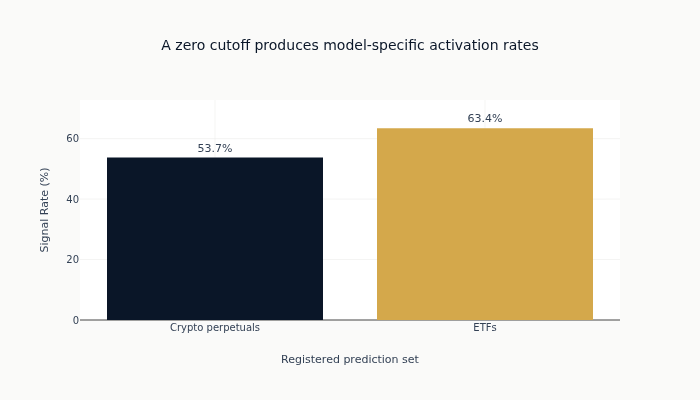

In [16]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=[CASE_STUDIES[cs]["display"] for cs in fixed_results["case_study"]],
        y=(fixed_results["signal_rate"] * 100).to_list(),
        marker_color=[CASE_STUDY_COLORS[case_study] for case_study in fixed_results["case_study"]],
        text=[f"{value:.1f}%" for value in fixed_results["signal_rate"] * 100],
        textposition="outside",
        showlegend=False,
    )
)

fig.update_layout(
    title="A zero cutoff produces model-specific activation rates",
    xaxis_title="Registered prediction set",
    yaxis_title="Signal Rate (%)",
    height=400,
)
fig.show()

## 6. Rolling Percentile Analysis

In [17]:
# Analyze rolling percentile results
rolling_results = (
    comparison_df.filter(pl.col("method") == "rolling_percentile")
    .select(["case_study", "window", "percentile", "signal_rate", "transition_rate"])
    .sort(["case_study", "window", "percentile"])
)

Each marker below identifies its lookback and percentile on hover.

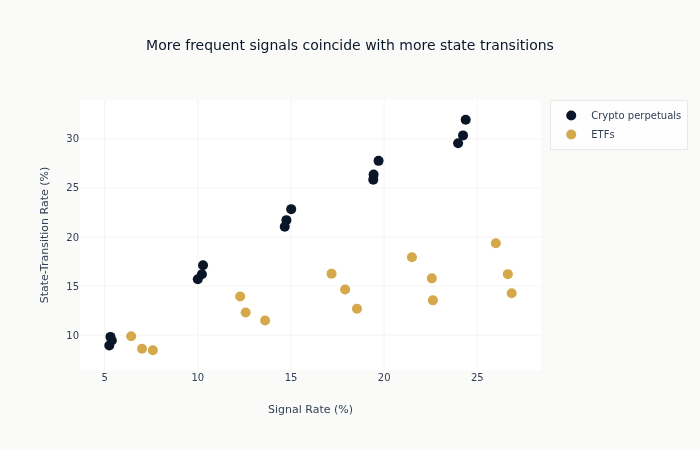

In [18]:
fig = go.Figure()

for case_study in CASE_STUDIES:
    data = comparison_df.filter(
        (pl.col("case_study") == case_study) & (pl.col("method") == "rolling_percentile")
    )
    fig.add_trace(
        go.Scatter(
            x=(data["signal_rate"] * 100).to_list(),
            y=(data["transition_rate"] * 100).to_list(),
            name=str(CASE_STUDIES[case_study]["display"]),
            mode="markers",
            marker=dict(size=10, color=CASE_STUDY_COLORS[case_study]),
            text=[
                f"window={window}, percentile={percentile}"
                for window, percentile in zip(data["window"], data["percentile"], strict=True)
            ],
            hovertemplate="%{text}<br>Signal: %{x:.1f}%<br>Transitions: %{y:.1f}%",
        )
    )

fig.update_layout(
    title="More frequent signals coincide with more state transitions",
    xaxis_title="Signal Rate (%)",
    yaxis_title="State-Transition Rate (%)",
    height=450,
)
fig.show()

## 7. A Common Descriptive Operating Point

The 90th percentile provides a common relative cutoff. The rolling version
shown here uses 63 observations; the cross-sectional version uses the current
universe. These are diagnostics on validation predictions, not a holdout-based
rule selection.

In [19]:
operating_points = comparison_df.filter(
    (pl.col("method") == "fixed_threshold")
    | (
        (pl.col("method") == "rolling_percentile")
        & (pl.col("window") == 63)
        & (pl.col("percentile") == 90)
    )
    | ((pl.col("method") == "cross_sectional") & (pl.col("percentile") == 90))
).select("case_study", "method", "signal_rate", "transition_rate", "n_dates")

The aligned panels compare all three conversion methods without implying that
their operating points were optimized. The fixed rule uses zero; both relative
rules use the 90th percentile, with a 63-observation rolling lookback.

In [20]:
method_order = ["fixed_threshold", "rolling_percentile", "cross_sectional"]
method_labels = ["Fixed > 0", "Rolling p90", "Cross-sectional p90"]
operating_plot_data = {
    case_study: (
        operating_points.filter(pl.col("case_study") == case_study)
        .with_columns(pl.col("method").replace_strict(method_order, [0, 1, 2]).alias("order"))
        .sort("order")
    )
    for case_study in CASE_STUDIES
}

The ordered plotting view keeps each method aligned across the two panels.

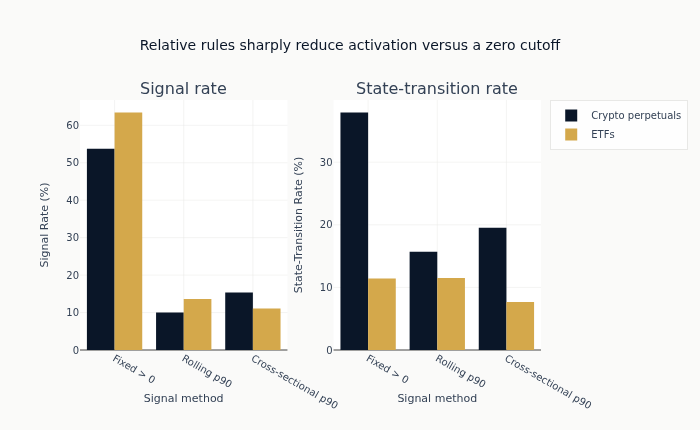

In [21]:
fig = make_subplots(rows=1, cols=2, subplot_titles=["Signal rate", "State-transition rate"])

for case_study in CASE_STUDIES:
    data = operating_plot_data[case_study]
    fig.add_trace(
        go.Bar(
            x=method_labels,
            y=(data["signal_rate"] * 100).to_list(),
            name=str(CASE_STUDIES[case_study]["display"]),
            marker_color=CASE_STUDY_COLORS[case_study],
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Bar(
            x=method_labels,
            y=(data["transition_rate"] * 100).to_list(),
            name=str(CASE_STUDIES[case_study]["display"]),
            marker_color=CASE_STUDY_COLORS[case_study],
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.update_layout(
    title="Relative rules sharply reduce activation versus a zero cutoff",
    barmode="group",
    height=430,
    margin=dict(t=100, r=140),
    legend=dict(x=1.02, y=1.0, xanchor="left", yanchor="top"),
)
fig.update_xaxes(title_text="Signal method", row=1, col=1)
fig.update_xaxes(title_text="Signal method", row=1, col=2)
fig.update_yaxes(title_text="Signal Rate (%)", row=1, col=1)
fig.update_yaxes(title_text="State-Transition Rate (%)", row=1, col=2)
fig.show()

## 8. Window Size Sensitivity

The left panel shows activation frequency; the right panel measures how often
a symbol changes state. Neither is portfolio turnover because position sizes
and traded notional are outside this notebook's scope.

In [22]:
lookback_plot_data = {
    case_study: comparison_df.filter(
        (pl.col("case_study") == case_study)
        & (pl.col("method") == "rolling_percentile")
        & (pl.col("percentile") == 90)
    ).sort("window")
    for case_study in CASE_STUDIES
}

Both panels use the same ordered lookback grid for each prediction set.

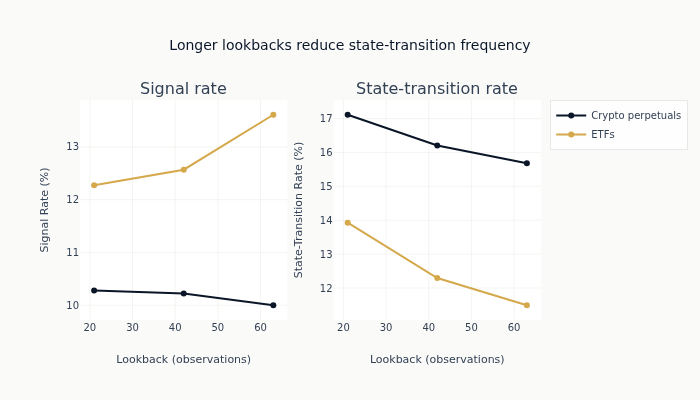

In [23]:
fig = make_subplots(rows=1, cols=2, subplot_titles=["Signal rate", "State-transition rate"])
for case_study in CASE_STUDIES:
    data = lookback_plot_data[case_study]
    fig.add_trace(
        go.Scatter(
            x=data["window"].to_list(),
            y=(data["signal_rate"] * 100).to_list(),
            name=str(CASE_STUDIES[case_study]["display"]),
            mode="lines+markers",
            line=dict(color=CASE_STUDY_COLORS[case_study]),
            marker=dict(color=CASE_STUDY_COLORS[case_study]),
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=data["window"].to_list(),
            y=(data["transition_rate"] * 100).to_list(),
            name=str(CASE_STUDIES[case_study]["display"]),
            mode="lines+markers",
            line=dict(color=CASE_STUDY_COLORS[case_study]),
            marker=dict(color=CASE_STUDY_COLORS[case_study]),
            showlegend=False,
        ),
        row=1,
        col=2,
    )
fig.update_layout(
    title="Longer lookbacks reduce state-transition frequency",
    height=400,
    margin=dict(t=100, r=140),
    legend=dict(x=1.02, y=1.0, xanchor="left", yanchor="top"),
)
fig.update_xaxes(title_text="Lookback (observations)", row=1, col=1)
fig.update_xaxes(title_text="Lookback (observations)", row=1, col=2)
fig.update_yaxes(title_text="Signal Rate (%)", row=1, col=1)
fig.update_yaxes(title_text="State-Transition Rate (%)", row=1, col=2)
fig.show()

## 9. Percentile Sensitivity

In [24]:
fig = make_subplots(rows=1, cols=2, subplot_titles=["Signal rate", "State-transition rate"])

for case_study in CASE_STUDIES:
    data = comparison_df.filter(
        (pl.col("case_study") == case_study)
        & (pl.col("method") == "rolling_percentile")
        & (pl.col("window") == 21)
    ).sort("percentile")

    fig.add_trace(
        go.Scatter(
            x=data["percentile"].to_list(),
            y=(data["signal_rate"] * 100).to_list(),
            name=str(CASE_STUDIES[case_study]["display"]),
            mode="lines+markers",
            line=dict(color=CASE_STUDY_COLORS[case_study]),
            marker=dict(color=CASE_STUDY_COLORS[case_study]),
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=data["percentile"].to_list(),
            y=(data["transition_rate"] * 100).to_list(),
            name=str(CASE_STUDIES[case_study]["display"]),
            mode="lines+markers",
            line=dict(color=CASE_STUDY_COLORS[case_study]),
            marker=dict(color=CASE_STUDY_COLORS[case_study]),
            showlegend=False,
        ),
        row=1,
        col=2,
    )

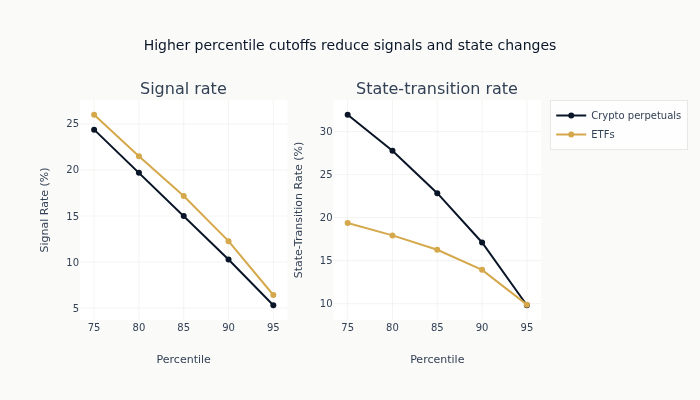

In [25]:
fig.update_layout(
    title="Higher percentile cutoffs reduce signals and state changes",
    height=400,
    margin=dict(t=100, r=140),
    legend=dict(x=1.02, y=1.0, xanchor="left", yanchor="top"),
)
fig.update_xaxes(title_text="Percentile", row=1, col=1)
fig.update_xaxes(title_text="Percentile", row=1, col=2)
fig.update_yaxes(title_text="Signal Rate (%)", row=1, col=1)
fig.update_yaxes(title_text="State-Transition Rate (%)", row=1, col=2)
fig.show()

## 10. Summary Across Evaluated Settings

Averaging over settings describes the design grid; it does not rank methods
economically because no portfolio returns or costs are computed here.

In [26]:
method_summary = (
    comparison_df.group_by("method")
    .agg(
        [
            pl.col("signal_rate").mean().alias("avg_signal_rate"),
            pl.col("signal_rate").std().alias("std_signal_rate"),
            pl.col("transition_rate").mean().alias("avg_transition_rate"),
            pl.col("transition_rate").std().alias("std_transition_rate"),
            pl.len().alias("n_settings"),
        ]
    )
    .sort("method")
)
method_summary

method,avg_signal_rate,std_signal_rate,avg_transition_rate,std_transition_rate,n_settings
str,f64,f64,f64,f64,u32
"""cross_sectional""",0.183699,0.073528,0.164704,0.083088,10
"""fixed_threshold""",0.585744,0.068501,0.246708,0.187637,2
"""rolling_percentile""",0.16041,0.069993,0.173326,0.069387,30


In [27]:
rolling_90 = operating_points.filter(pl.col("method") == "rolling_percentile")
display(
    Markdown(
        "At the common 63-observation, 90th-percentile operating point, signal rates span "
        f"**{rolling_90['signal_rate'].min() * 100:.1f}% to "
        f"{rolling_90['signal_rate'].max() * 100:.1f}%**, while state-transition rates span "
        f"**{rolling_90['transition_rate'].min() * 100:.1f}% to "
        f"{rolling_90['transition_rate'].max() * 100:.1f}%**. "
        "These are implementation diagnostics, not return or cost estimates."
    )
)

At the common 63-observation, 90th-percentile operating point, signal rates span **10.0% to 13.6%**, while state-transition rates span **11.5% to 15.7%**. These are implementation diagnostics, not return or cost estimates.

## 11. Write Reusable Diagnostics

In [28]:
OUTPUT_DIR = get_output_dir(16, "signal_method_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_df.write_parquet(OUTPUT_DIR / "method_comparison.parquet")
method_summary.write_parquet(OUTPUT_DIR / "method_summary.parquet")
print(f"Wrote {comparison_df.height} method-setting rows and {method_summary.height} summaries")

Wrote 42 method-setting rows and 3 summaries


## Key Takeaways

1. **Signal conversion changes portfolio inputs**: The same prediction set
   produces different activation and state-transition rates under fixed,
   rolling-percentile, and cross-sectional rules.

2. **Cross-sectional methods adapt to changing signal distributions**: by
   selecting the top quantile, they produce a positive signal rate by
   construction, regardless of where the prediction distribution sits. The
   comparison panels report the measured values; fixed-threshold methods can
   collapse to zero when predictions never cross the cutoff. The notebook
   does not separately evaluate regime-conditional consistency - only
   configuration-level signal-rate dispersion.

3. **Percentile choices remain design choices**: The sensitivity panels show
   how lookback and cutoff settings alter the signal stream before any return
   backtest or cost model is applied.

4. **State transitions are not portfolio turnover**: Position sizes, traded
   notional, and costs must be evaluated in the downstream backtest before an
   economic rule can be selected.

**Next**: `09_performance_reporting` shows how to evaluate realized strategy
returns once the signal, position sizing, and cost protocol are fixed.

**Book**: Section 16.2 discusses the trading protocol specification that
determines how signals become positions.